In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──

import sys
from pathlib import Path
from collections import OrderedDict
import json
import re
from datetime import datetime, timezone

from scipy.stats import fisher_exact, chi2_contingency
from statsmodels.stats.contingency_tables import Table2x2
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint

_HERE = Path.cwd().resolve()
_REPO = None
for _d in [_HERE, *_HERE.parents]:
    if (_d / "studies" / "garlic" / "garlic.py").is_file():
        _REPO = _d
        break
if _REPO is None:
    raise FileNotFoundError("Could not locate studies/garlic/garlic.py walking up from cwd")
sys.path.insert(0, str(_REPO / "studies" / "garlic"))
import garlic as G  # noqa: E402

G.apply_style(plt)
plt.rcParams.update({"figure.figsize": (9.2, 5.0), "figure.dpi": 120, "font.size": 10})
pd.set_option("future.no_silent_downcasting", True)

DB_PATH = str(G.db_path())
conn = G.open_db()
F = G.load_frames()

COMPLETE = pd.Index(F.units.loc[F.units.status == "complete", "reporter"].unique())
N_REP = int(len(COMPLETE))
N_MEMBERS = int(len(F.members))
USE = F.claims.loc[F.claims.use_payload_allowed].copy()
N_USE = int(USE.reporter.nunique())
BELIEF = F.claims.loc[F.claims.polarity.notna() & F.claims.included.astype(bool)].copy()
N_BELIEF = int(BELIEF.reporter.nunique())
ACTS = (
    G.reporter_matrix(F, "speech_act", G.SPEECH_ACTS)
    .reindex(COMPLETE, fill_value=False)
    .astype(bool)
)
ONLY_FL = ACTS["food_list"] & ~ACTS["actual_use"]
ONLY_AU = ACTS["actual_use"] & ~ACTS["food_list"]
BOTH_FL_AU = ACTS["food_list"] & ACTS["actual_use"]
POL = pd.crosstab(BELIEF["reporter"], BELIEF["polarity"]).gt(0)
MECH = pd.crosstab(F.mechanisms["reporter"], F.mechanisms["mechanism"]).gt(0)
ALLICIN_SYS = ["antimicrobial", "gut_or_biofilm", "immune", "herx_or_dieoff"]
HIST_SYS = ["histamine_or_mcas_trigger", "allium_intolerance"]
HAS_ALLICIN = MECH[[c for c in ALLICIN_SYS if c in MECH.columns]].any(axis=1)
HAS_HIST = MECH[[c for c in HIST_SYS if c in MECH.columns]].any(axis=1)
HAS_CARDIO = (
    MECH["cardiovascular_or_bleeding"]
    if "cardiovascular_or_bleeding" in MECH.columns
    else pd.Series(False, index=MECH.index)
)

JSON_PATH = _REPO / "data" / "full_corpus_2026-07-31" / "records_covidlonghaulers_v2.json"
REDDIT_PATH = _REPO / "reddit_2026-06-13.db"
JSON_GARLIC_RE = re.compile(
    r"\bgarlic\b|\ballicin\b|\bkyolic\b|\ballium sativum\b", re.IGNORECASE
)

PALETTE = {
    "pro": "#2b6cb0",
    "anti": "#c53030",
    "mixed": "#dd6b20",
    "unclear": "#a0aec0",
    "accent": "#2c5282",
    "food": "#c53030",
    "use": "#2b6cb0",
    "cardio": "#319795",
    "other": "#718096",
    "json": "#6b46c1",
    "fts": "#2b6cb0",
}


def show(df, caption=None, percent_cols=(), int_cols=(), float_cols=(), drop_cols=()):
    out = df.copy()
    drop = [c for c in drop_cols if c in out.columns]
    if drop:
        out = out.drop(columns=drop)
    for c in percent_cols:
        if c in out.columns:
            out[c] = out[c].map(lambda x: "—" if pd.isna(x) else f"{100 * x:.1f}%")
    for c in int_cols:
        if c in out.columns:
            out[c] = out[c].map(lambda x: "—" if pd.isna(x) else f"{int(x):,}")
    for c in float_cols:
        if c in out.columns:
            out[c] = out[c].map(lambda x: "—" if pd.isna(x) else f"{float(x):.2f}")
    if "headline" in out.columns:
        out["n ≥ 30"] = out["headline"].map(lambda x: "yes" if bool(x) else "no")
        out = out.drop(columns=["headline"])
    html = out.to_html(index=False, escape=True)
    cap = f"<p style='margin:0 0 6px 0;color:#4a5568;font-size:0.95em'>{caption}</p>" if caption else ""
    display(HTML(cap + html))


def callout(kind, text):
    colors = {
        "caution": ("#c53030", "#fff5f5"),
        "note": ("#2b6cb0", "#ebf8ff"),
        "finding": ("#276749", "#f0fff4"),
    }
    border, bg = colors[kind]
    display(HTML(
        f"<div style='border-left:4px solid {border};background:{bg};"
        f"padding:10px 14px;margin:8px 0'>{text}</div>"
    ))


def wilson_k(k, n):
    est, lo, hi = G.wilson(int(k), int(n))
    return est, lo, hi


def fisher_html(k1, n1, k2, n2, a, b, outcome):
    table = np.array([[k1, n1 - k1], [k2, n2 - k2]], dtype=int)
    or_, p = fisher_exact(table)
    t2 = Table2x2(table)
    lo, hi = t2.oddsratio_confint()
    h = G.cohens_h(k1 / n1, k2 / n2)
    warn = []
    if min(n1, n2) < 15:
        warn.append("unreliable: small_sample")
    elif min(n1, n2) < 20:
        warn.append("caveat: small_sample")
    if max(n1, n2) / max(min(n1, n2), 1) > 4:
        warn.append("caveat: imbalanced_samples")
    if (table < 5).any():
        warn.append("caveat: sparse_cells")
    p_txt = f"p = {p:.3g}" if p >= 1e-4 else f"p = {p:.2e}"
    display(HTML(
        "<p><b>Test.</b> Fisher’s exact on "
        f"{outcome}: {a} {k1}/{n1} ({100*k1/n1:.1f}%) vs {b} {k2}/{n2} "
        f"({100*k2/n2:.1f}%). Odds ratio {or_:.2f} (95% CI {lo:.2f}–{hi:.2f}), "
        f"{p_txt}, Cohen’s h = {h:.2f}."
        + (f" <i>{'; '.join(warn)}</i>." if warn else "")
        + "</p>"
    ))
    return {"or": or_, "or_lo": lo, "or_hi": hi, "p": p, "h": h}


def polarity_counts(mask):
    ids = mask[mask].index
    sub = POL.reindex(ids).fillna(False).astype(bool)
    sub = sub.loc[sub.any(axis=1)]
    out = {"n_group": int(mask.sum()), "n_polarity": int(len(sub))}
    for col in ("pro_use", "anti_use", "mixed", "unclear"):
        out[col] = int(sub[col].sum()) if col in sub.columns else 0
    return out, sub


def fig_show(fig):
    fig.tight_layout()
    display(fig)
    plt.close(fig)


def forest(ax, labels, rates, los, his, ns, color, xlabel):
    y = np.arange(len(labels))[::-1]
    rates, los, his = np.asarray(rates, float), np.asarray(los, float), np.asarray(his, float)
    ax.barh(
        y, rates,
        xerr=np.vstack([np.clip(rates - los, 0, None), np.clip(his - rates, 0, None)]),
        height=0.62, color=color, error_kw={"lw": 0.9, "ecolor": "#2d3748", "capsize": 2},
    )
    ax.set_yticks(y, [f"{lab}   n={n:,}" for lab, n in zip(labels, ns)])
    ax.set_xlabel(xlabel)
    ax.set_xlim(0, min(1.0, max(his) * 1.18 if len(his) else 1))
    return ax

import collections

GARLIC_TOKEN_RE = re.compile(r"garlic|allicin|kyolic", re.IGNORECASE)

ANTICOAG_RE = (
    r"nattokinase|serrapeptase|serrazime|lumbrokinase|bromelain|aspirin|warfarin|"
    r"eliquis|apixaban|xarelto|rivaroxaban|clopidogrel|plavix|heparin"
)
MICROCLOT_RE = r"microclot|micro-clot|micro clot|fibrin|amyloid"
SMELL_RE = (
    r"parosmi|phantosmi|anosmi|smell (loss|training)|"
    r"lost (my )?(sense of )?(smell|taste)|"
    r"taste(s)? like (wet )?(garbage|rot|chemical|sewage|gasoline)|"
    r"distorted (smell|taste)"
)
LISTY_RE = (
    r"\b(avoid|trigger|eliminat|cut out|intoleran|histamine|fodmap|sensitiv|react)"
)


def _reporter_ids(con):
    # Rebuild load_frames' dense author_hash -> reporter map (first-seen order).
    ids = {}
    for (h,) in con.execute(
        "SELECT author_hash FROM cohort_member WHERE run_id = ?", (G.RUN_ID,)):
        ids.setdefault(h, len(ids))
    for (h,) in con.execute(
        "SELECT author_hash FROM unit WHERE run_id = ?", (G.RUN_ID,)):
        ids.setdefault(h, len(ids))
    return ids


def text_flags(patterns):
    # Regex flags over raw window text, as a frame indexed by reporter. Raw text
    # is concatenated, matched and discarded inside this function; only booleans
    # and a garlic-token count are returned.
    con = G.open_db()
    try:
        ids = _reporter_ids(con)
        status = dict(con.execute(
            "SELECT unit_key, status FROM unit WHERE run_id = ?", (G.RUN_ID,)))
        unit_rep = {k: ids[h] for k, h in con.execute(
            "SELECT unit_key, author_hash FROM unit WHERE run_id = ?", (G.RUN_ID,))}
        buf = collections.defaultdict(list)
        for unit_key, text in con.execute(
            "SELECT unit_key, text FROM source_window WHERE run_id = ?", (G.RUN_ID,)):
            if status.get(unit_key) == "complete":
                buf[unit_rep[unit_key]].append((text or "").lower())
    finally:
        con.close()
    rows = {}
    for rep, parts in buf.items():
        blob = " ".join(parts)
        row = {name: bool(re.search(p, blob)) for name, p in patterns.items()}
        row["garlic_tokens"] = len(GARLIC_TOKEN_RE.findall(blob))
        rows[rep] = row
    return pd.DataFrame.from_dict(rows, orient="index").sort_index()


def quote_flags(patterns):
    # Regex flags over stored evidence quotes, as a frame indexed by claim_id.
    # Quote text is matched and discarded inside this function.
    con = G.open_db()
    try:
        rows = {}
        for claim_id, evidence_json in con.execute(
            "SELECT claim_id, evidence_json FROM claim WHERE run_id = ?", (G.RUN_ID,)):
            blob = " ".join(
                e.get("quote", "") for e in json.loads(evidence_json or "[]")).lower()
            rows[claim_id] = {n: bool(re.search(p, blob)) for n, p in patterns.items()}
    finally:
        con.close()
    return pd.DataFrame.from_dict(rows, orient="index").sort_index()


def anti_use_contrast(exclude_own_act):
    # Anti-use polarity in exclusive food_list vs exclusive actual_use camps.
    # `exclude_own_act` drops the camp-defining speech act from the polarity
    # source, so polarity comes from a different claim than the camp label.
    out = {}
    for camp, mask in (("food_list", ONLY_FL), ("actual_use", ONLY_AU)):
        ids = set(mask[mask].index)
        b = BELIEF[BELIEF.reporter.isin(ids)]
        if exclude_own_act:
            b = b[b.speech_act != camp]
        g = b.groupby("reporter").polarity.apply(lambda s: "anti_use" in set(s))
        out[camp] = (int(g.sum()), int(len(g)))
    (k1, n1), (k2, n2) = out["food_list"], out["actual_use"]
    or_, p = fisher_exact([[k1, n1 - k1], [k2, n2 - k2]])
    return {"k_fl": k1, "n_fl": n1, "k_au": k2, "n_au": n2,
            "OR": or_, "p": p, "h": G.cohens_h(k1 / n1, k2 / n2)}


TEXT = text_flags({
    "anticoagulant": ANTICOAG_RE,
    "microclot": MICROCLOT_RE,
    "smell_taste": SMELL_RE,
})


# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score.

    Unrecognized/missing labels return NaN (excluded from means) rather than
    0.0, to avoid silently biasing averages toward neutral.
    """
    return SENTIMENT_SCORE.get(s, np.nan)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score is None or pd.isna(avg_score):
        return None
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if pd.isna(k) or pd.isna(n) or n <= 0 or k < 0 or k > n:
        return np.nan, np.nan
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0.0, center - margin), min(1.0, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal, inverted, or invalid."""
    if pd.isna(treatment_rate) or pd.isna(baseline_rate):
        return None
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors — include both aggregated ("mixed/neutral") and raw DB labels
# ("mixed", "neutral") so charts can key off either without a KeyError.
COLORS = {
    "positive": "#2ecc71",
    "mixed/neutral": "#95a5a6",
    "mixed": "#95a5a6",
    "neutral": "#95a5a6",
    "negative": "#e74c3c",
}


**Research question (v2):** "How much of the v1 headline — a 39-fold split between garlic-as-food-list and garlic-as-treatment — is a fact about the community, and how much is an artefact of one model labelling both variables in the same breath? And what is this corpus saying that v1's closed vocabulary had no slot for?"


# Garlic beliefs and use, v2: what survives an independence check

**Abstract.** This is a re-analysis of the same probe store, run id and extraction model as v1 (`deepseek/deepseek-v4-flash`, run `c05891b6…`); nothing was re-extracted. Every v1 count reproduces exactly. Three things change. **(1)** v1's headline contrast is inflated by same-claim labelling: `speech_act` and `polarity` are emitted in one JSON object, and the claim-level split (73.3% vs 6.2% anti-use) already equals the reporter-level headline. Sourcing polarity only from claims *other* than the camp-defining one, the split holds but falls from OR 38.8 (h = 1.59) to **OR 15.3 (h = 1.18)**. The two-system finding is real and should be reported at roughly the latter size. **(2)** v1's second finding — that a first-pass `treatment_outcome` field selects the use camp — survives the obvious confound. Stratifying by how many garlic tokens an account wrote, the odds ratio stays between 12.5 and 18.8 in every stratum; among accounts mentioning garlic exactly once it is 70.9% vs 13.5%. This, not the polarity split, is the strongest result in either notebook. **(3)** Two categories are missing from the schema. **113 of 640** self + actual-use accounts write about garlic alongside an anticoagulant or fibrinolytic (nattokinase, serrapeptase, aspirin, apixaban); 2 produce any `warning` claim and 1 a bleeding adverse event. And **61 accounts** describe parosmia or flavour loss, which has no mechanism label — 22 of them are scored `food_list`, feeding the anti-use camp with a mechanism that is not histamine.

Same caveats as v1: shares of extractable reports at the account level, not efficacy, incidence or dose-response.


## What v2 changes

| v1 said | v2 finds | Direction |
|---|---|---|
| Polarity split OR 38.8, Cohen's h 1.59, **Strong** tier | OR 15.3, h 1.18 when polarity is taken from a different claim | Real, ~2.5× smaller; demote to **Moderate** |
| JSON-vs-FTS split, **Strong** tier | Flat OR 12.5–18.8 across garlic-volume strata | Confirmed; **promote to the lead finding** |
| Circulation is "a third camp", framed as a taxonomy surprise | It is the microclot/blood-thinner protocol, and it is a safety gap | Reframed, new |
| "Some list-shaped posts may be landing in `culinary`" | 1% of culinary quotes carry trigger language vs 34% of food_list | v1's self-critique points the wrong way |
| Parosmia | Not in the schema; 61 accounts, 22 mislabelled `food_list` | New |
| Wilson CIs on account shares | 42 accounts carry 19.6% of claims; camps differ in claims/account | Independence is weaker than the CIs imply |

Everything else in v1 — the preparation mix, the mechanism FDR scan, the gut/biofilm null, the Stage 5b agreement — reproduces and is not restated here.


> **Inherited caution (GATE 4).** A blind labelling pass on 80 windows agreed with the model on only 5 of 12 rows where either party assigned `food_list`, `avoidance` or `culinary`. Those labels remain provisional in v2, and §5 shows the failure is not the one v1 guessed.


## 0. Verification: v1 reproduces exactly

Before re-testing anything, confirm the v2 environment reads the same run and returns v1's numbers. These are recomputed from the store, not copied.


In [2]:

acts_tbl = pd.DataFrame([
    {"speech act": a, "accounts": int(ACTS[a].sum()),
     "v1 reported": {"actual_use": 650, "culinary": 408, "food_list": 355,
                     "recommendation": 297, "mechanism_belief": 179, "other": 166,
                     "question": 164, "avoidance": 109, "planned_or_considered": 96,
                     "warning": 15}.get(a)}
    for a in G.SPEECH_ACTS
]).sort_values("accounts", ascending=False).reset_index(drop=True)
acts_tbl["match"] = np.where(acts_tbl["accounts"] == acts_tbl["v1 reported"], "✓", "✗")
show(acts_tbl, f"Reporter-level speech-act presence over {N_REP:,} complete-extraction accounts. An account may hold more than one act.",
     int_cols=("accounts", "v1 reported"))

primary = anti_use_contrast(exclude_own_act=False)
ok = (primary["k_fl"], primary["n_fl"], primary["k_au"], primary["n_au"]) == (144, 181, 36, 395)
callout("finding" if ok else "caution",
        f"<b>v1 headline reproduces:</b> food_list {primary['k_fl']}/{primary['n_fl']} "
        f"({100*primary['k_fl']/primary['n_fl']:.1f}%) vs actual_use {primary['k_au']}/{primary['n_au']} "
        f"({100*primary['k_au']/primary['n_au']:.1f}%) anti-use, OR = {primary['OR']:.1f}, "
        f"Cohen’s h = {primary['h']:.2f}. {'Exact match to v1.' if ok else 'MISMATCH — investigate.'}")


speech act,accounts,v1 reported,match
actual_use,650,650,✓
culinary,408,408,✓
food_list,355,355,✓
recommendation,297,297,✓
mechanism_belief,179,179,✓
other,166,166,✓
question,164,164,✓
avoidance,109,109,✓
planned_or_considered,96,96,✓
warning,15,15,✓


## 1. How much of the headline is the model labelling itself?

`speech_act` and `polarity` are two fields of one JSON object emitted in one pass. v1 notes this under Confounding but still reports the contrast at full size. The test is cheap: if the split were a fact about accounts rather than about sentences, aggregating claims to accounts should *add* signal. It does not — the claim-level table below already carries the whole effect.


polarity,speech act,pro_use,anti_use,mixed,unclear,(none),anti-use % of scored
,actual_use,719,50,24,10,609,6.20
,food_list,66,211,9,2,203,73.30
,culinary,6,1,1,0,486,12.50
,recommendation,332,16,6,0,101,4.50
,mechanism_belief,145,35,10,15,12,17.10
,question,23,8,4,9,144,18.20
,other,7,11,2,0,171,55.00
,avoidance,0,91,2,0,45,97.80
,planned_or_considered,55,1,5,0,55,1.60
,warning,0,13,3,2,3,72.20


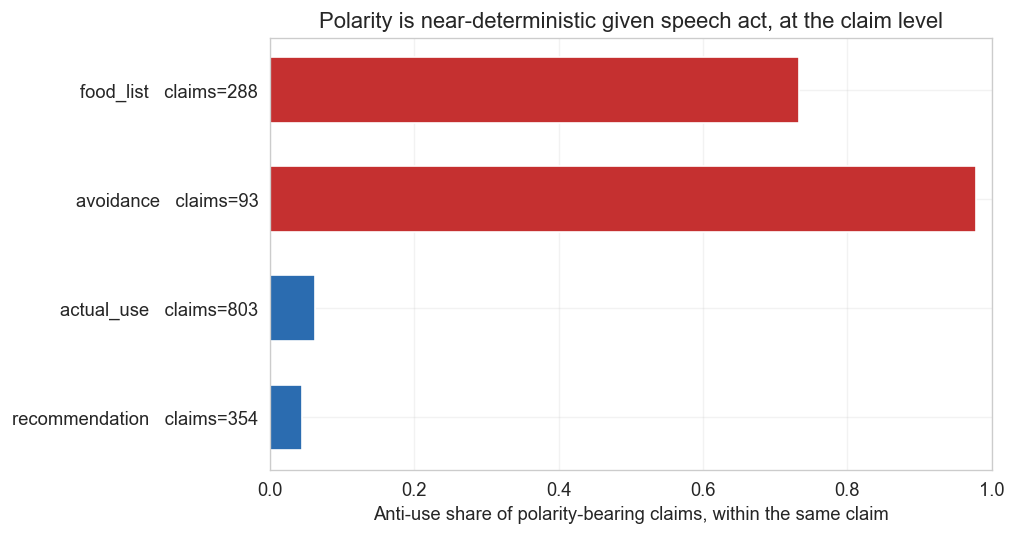

In [3]:

ct = (F.claims.assign(polarity=F.claims.polarity.fillna("(none)"))
      .pivot_table(index="speech_act", columns="polarity", aggfunc="size", fill_value=0))
order = [c for c in ("pro_use", "anti_use", "mixed", "unclear", "(none)") if c in ct.columns]
ct = ct[order].reindex([a for a in G.SPEECH_ACTS if a in ct.index])
scored = ct[[c for c in order if c != "(none)"]].sum(axis=1)
ct_disp = ct.copy()
ct_disp["anti-use % of scored"] = np.where(
    scored > 0, (100 * ct["anti_use"] / scored.replace(0, np.nan)).round(1), np.nan)
show(ct_disp.reset_index().rename(columns={"speech_act": "speech act"}),
     "Claim-level cross-tab of the two fields the headline contrasts, in the same JSON object. "
     "The 73.3% / 6.2% food_list-vs-actual_use gap here is already the reporter-level headline.",
     float_cols=("anti-use % of scored",))

fig, ax = plt.subplots(figsize=(8.6, 4.6))
sub = ct_disp.loc[[a for a in ("food_list", "avoidance", "actual_use", "recommendation")
                   if a in ct_disp.index]]
y = np.arange(len(sub))[::-1]
ax.barh(y, sub["anti-use % of scored"] / 100, height=0.6,
        color=[PALETTE["food"] if v > 0.5 else PALETTE["use"]
               for v in sub["anti-use % of scored"] / 100])
ax.set_yticks(y, [f"{a}   claims={int(n):,}" for a, n in zip(sub.index, scored.loc[sub.index])])
ax.set_xlabel("Anti-use share of polarity-bearing claims, within the same claim")
ax.set_xlim(0, 1)
ax.set_title("Polarity is near-deterministic given speech act, at the claim level")
fig_show(fig)


polarity source,food_list anti-use,actual_use anti-use,OR,p,h
any claim (v1 primary),144/181 (79.6%),36/395 (9.1%),38.81,9.12e-65,1.59
claims other than the camp-defining act,18/29 (62.1%),11/114 (9.6%),15.32,1.38e-08,1.18


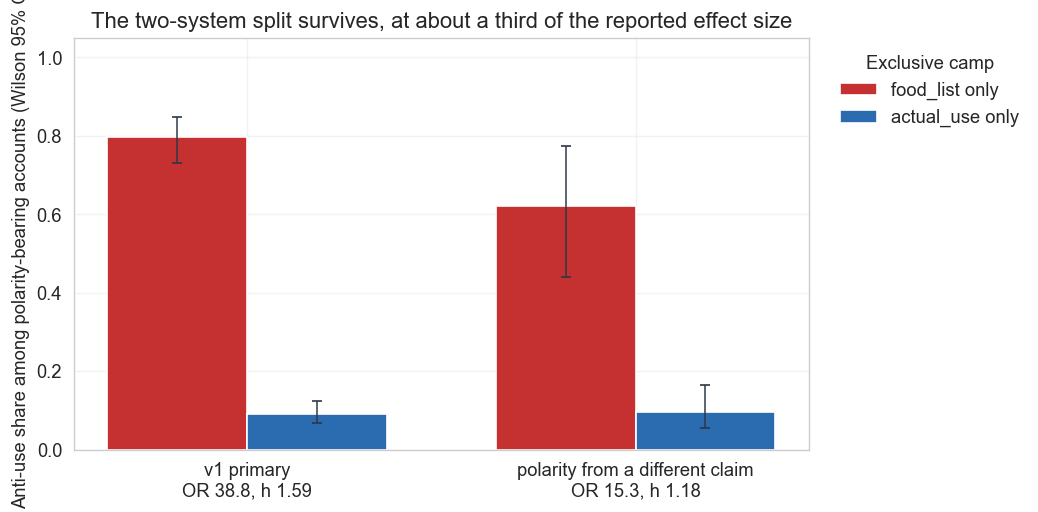

In [4]:

cross = anti_use_contrast(exclude_own_act=True)
rows = pd.DataFrame([
    {"polarity source": "any claim (v1 primary)", **primary},
    {"polarity source": "claims other than the camp-defining act", **cross},
])
rows["food_list anti-use"] = [f"{r.k_fl}/{r.n_fl} ({100*r.k_fl/r.n_fl:.1f}%)" for r in rows.itertuples()]
rows["actual_use anti-use"] = [f"{r.k_au}/{r.n_au} ({100*r.k_au/r.n_au:.1f}%)" for r in rows.itertuples()]
show(rows[["polarity source", "food_list anti-use", "actual_use anti-use", "OR", "p", "h"]]
     .assign(p=lambda d: d.p.map("{:.2e}".format)),
     "Exclusive camps. The second row is the same contrast with the circularity removed: an account's "
     "camp comes from one claim, its polarity from a different one. Sample is much smaller because most "
     "accounts write a single claim.",
     float_cols=("OR", "h"))
_ = fisher_html(cross["k_fl"], cross["n_fl"], cross["k_au"], cross["n_au"],
                "food_list only", "actual_use only", "anti-use polarity from a different claim")

fig, ax = plt.subplots(figsize=(8.8, 4.4))
x = np.arange(2); width = 0.36
for i, (lab, color, key) in enumerate((("food_list only", PALETTE["food"], ("k_fl", "n_fl")),
                                       ("actual_use only", PALETTE["use"], ("k_au", "n_au")))):
    pts = [wilson_k(d[key[0]], d[key[1]]) for d in (primary, cross)]
    rates = np.array([p[0] for p in pts])
    lo = np.array([p[1] for p in pts]); hi = np.array([p[2] for p in pts])
    ax.bar(x + (i - 0.5) * width, rates, width, color=color, label=lab,
           yerr=np.vstack([rates - lo, hi - rates]), capsize=3,
           error_kw={"lw": 0.9, "ecolor": "#2d3748"})
ax.set_xticks(x, [f"v1 primary\nOR {primary['OR']:.1f}, h {primary['h']:.2f}",
                  f"polarity from a different claim\nOR {cross['OR']:.1f}, h {cross['h']:.2f}"])
ax.set_ylabel("Anti-use share among polarity-bearing accounts (Wilson 95% CI)")
ax.set_ylim(0, 1.05)
ax.legend(title="Exclusive camp", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
ax.set_title("The two-system split survives, at about a third of the reported effect size")
fig_show(fig)

callout("finding",
        f"<b>Verdict.</b> The split is not an artefact — {100*cross['k_fl']/cross['n_fl']:.0f}% vs "
        f"{100*cross['k_au']/cross['n_au']:.0f}% at p = {cross['p']:.1e} on independent claims. But the "
        f"headline effect size is inflated about {primary['OR']/cross['OR']:.1f}× by within-claim coupling. "
        f"Report OR ≈ {cross['OR']:.0f}, not {primary['OR']:.0f}. The cross-claim cut rests on "
        f"{cross['n_fl']} food-list accounts, so it is a direction check, not a precise estimate.")


## 2. The methods finding, stress-tested

v1's second headline: accounts the first-pass extractor already tagged with garlic are overwhelmingly labelled `actual_use`, while accounts only full-text search retrieved are not. The obvious objection is salience — maybe the first pass simply caught the people who wrote *more* about garlic, and volume drives the use label. JSON-garlic accounts do write more. Stratify on that and see whether the effect survives.


garlic tokens written,JSON n,JSON actual_use,FTS-only n,FTS-only actual_use,OR,p
1,206,70.9%,978,13.5%,15.60,5.70e-60
2,94,78.7%,233,16.7%,18.41,3.10e-26
3–4,89,84.3%,137,29.9%,12.54,3.78e-16
5–9,66,92.4%,61,39.3%,18.81,8.55e-11
10+,45,97.8%,18,77.8%,12.57,0.0208


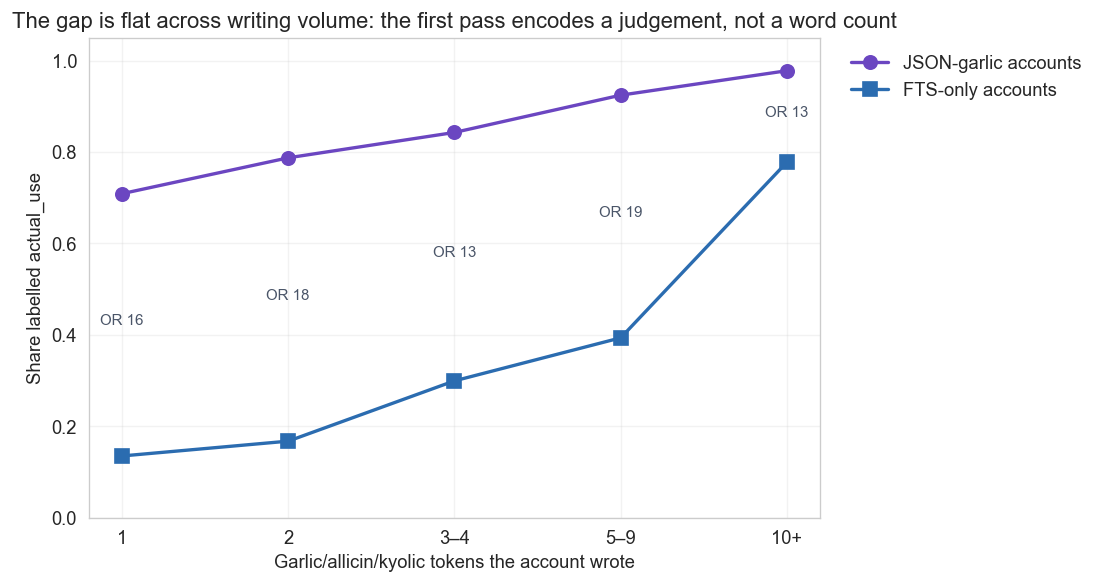

In [5]:

json_reps = set()
if JSON_PATH.is_file():
    _con = G.open_db()
    try:
        _ids = _reporter_ids(_con)
    finally:
        _con.close()
    for rec in json.loads(JSON_PATH.read_text()):
        if JSON_GARLIC_RE.search(json.dumps(rec.get("fields", {}), ensure_ascii=False)):
            h = rec["record_meta"]["author_hash"]
            if h in _ids:
                json_reps.add(_ids[h])
    del _ids

J = sorted(set(COMPLETE) & json_reps)
Fo = sorted(set(COMPLETE) - json_reps)
AU = ACTS["actual_use"]
tok = TEXT["garlic_tokens"]

strata = [(1, 1, "1"), (2, 2, "2"), (3, 4, "3–4"), (5, 9, "5–9"), (10, 10**6, "10+")]
rows = []
for lo, hi, lab in strata:
    js = [r for r in J if lo <= tok.get(r, 0) <= hi]
    fs = [r for r in Fo if lo <= tok.get(r, 0) <= hi]
    if min(len(js), len(fs)) < 5:
        continue
    k1 = int(AU.reindex(js).fillna(False).sum()); k2 = int(AU.reindex(fs).fillna(False).sum())
    or_, p = fisher_exact([[k1, len(js) - k1], [k2, len(fs) - k2]])
    rows.append({"garlic tokens written": lab, "JSON n": len(js), "JSON actual_use": k1 / len(js),
                 "FTS-only n": len(fs), "FTS-only actual_use": k2 / len(fs), "OR": or_, "p": p})
strat = pd.DataFrame(rows)
show(strat.assign(p=lambda d: d.p.map(lambda x: f"{x:.2e}" if x < 1e-4 else f"{x:.3g}")),
     f"Actual-use labelling among JSON-garlic (n = {len(J):,}) vs FTS-only (n = {len(Fo):,}) complete accounts, "
     "stratified by how many garlic/allicin/kyolic tokens the account actually wrote. If the v1 finding were a "
     "salience artefact, the odds ratio would collapse toward 1 in the low strata.",
     percent_cols=("JSON actual_use", "FTS-only actual_use"),
     int_cols=("JSON n", "FTS-only n"), float_cols=("OR",))

fig, ax = plt.subplots(figsize=(9.2, 5.0))
x = np.arange(len(strat))
ax.plot(x, strat["JSON actual_use"], "o-", color=PALETTE["json"], lw=2, ms=8, label="JSON-garlic accounts")
ax.plot(x, strat["FTS-only actual_use"], "s-", color=PALETTE["fts"], lw=2, ms=8, label="FTS-only accounts")
for xi, jr, fr, or_ in zip(x, strat["JSON actual_use"], strat["FTS-only actual_use"], strat["OR"]):
    ax.annotate(f"OR {or_:.0f}", (xi, (jr + fr) / 2), ha="center", fontsize=9, color="#4a5568")
ax.set_xticks(x, strat["garlic tokens written"])
ax.set_xlabel("Garlic/allicin/kyolic tokens the account wrote")
ax.set_ylabel("Share labelled actual_use")
ax.set_ylim(0, 1.05)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_title("The gap is flat across writing volume: the first pass encodes a judgement, not a word count")
fig_show(fig)

callout("finding",
        f"<b>Verdict.</b> The odds ratio stays between {strat.OR.min():.1f} and {strat.OR.max():.1f} in every "
        f"stratum. Among accounts that mention garlic exactly once, "
        f"{100*strat.iloc[0]['JSON actual_use']:.1f}% of JSON-garlic accounts are labelled actual_use against "
        f"{100*strat.iloc[0]['FTS-only actual_use']:.1f}% of FTS-only accounts. Salience does not explain it. "
        "This is the most robust result in either notebook, and it is a fact about the pipeline, not about garlic.")


## 3. The circulation camp is the microclot protocol — and nobody is warning about it

v1 found `cardiovascular_or_bleeding` to be the second-largest mechanism, noted it sits with the use camp "mostly as pro-use … not as an anticoagulant warning," and filed it as a surprise about the design's two-system frame. Read against the corpus, that absence of warnings is the finding. Garlic has documented antiplatelet activity; this community is stacking it *deliberately* with nattokinase, serrapeptase and prescription anticoagulants, as part of the long-COVID microclot protocol.


group,accounts
self + actual_use accounts,640
…co-writing an anticoagulant / fibrinolytic,113
"…of those, any `warning` claim",2
"…of those, a bleeding/anticoagulant adverse event",1
"…of those, ANY adverse event reported",17
"bleeding/anticoagulant AE, whole cohort",3
"`warning` speech act, whole cohort",15


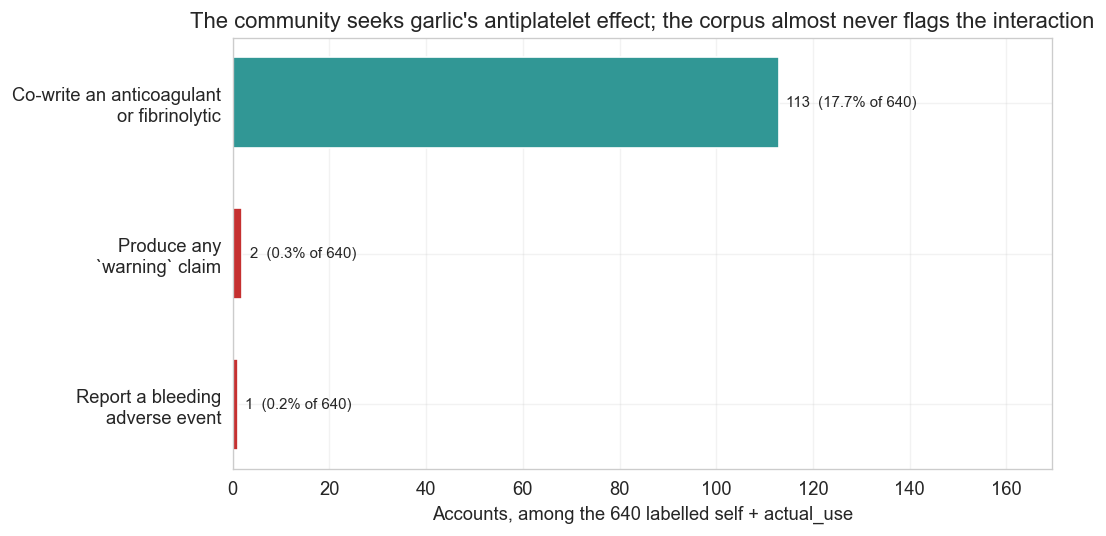

In [6]:

use_reps = set(USE.reporter.unique())
warn_reps = set(F.claims.loc[F.claims.speech_act == "warning", "reporter"])
bleed_reps = set(F.adverse.loc[F.adverse.category == "bleeding_or_anticoagulant", "reporter"])
ae_reps = set(F.claims.loc[F.claims.adverse_event_status == "reported", "reporter"])
anticoag = set(TEXT.index[TEXT["anticoagulant"]])
microclot = set(TEXT.index[TEXT["microclot"]])

stack = use_reps & anticoag
gap = pd.DataFrame([
    {"group": "self + actual_use accounts", "accounts": len(use_reps)},
    {"group": "…co-writing an anticoagulant / fibrinolytic", "accounts": len(stack)},
    {"group": "…of those, any `warning` claim", "accounts": len(stack & warn_reps)},
    {"group": "…of those, a bleeding/anticoagulant adverse event", "accounts": len(stack & bleed_reps)},
    {"group": "…of those, ANY adverse event reported", "accounts": len(stack & ae_reps)},
    {"group": "bleeding/anticoagulant AE, whole cohort", "accounts": len(bleed_reps)},
    {"group": "`warning` speech act, whole cohort", "accounts": len(warn_reps)},
])
show(gap, "Co-mention is not co-ingestion: the flag says an anticoagulant or fibrinolytic name appears in the "
          "same account's garlic windows. It is an upper bound on stacking and a lower bound on the reporting gap.",
     int_cols=("accounts",))

base = len(anticoag & set(COMPLETE)) / len(COMPLETE)
in_use = len(stack) / len(use_reps)
_ = fisher_html(len(stack), len(use_reps),
                len(anticoag & set(COMPLETE)) - len(stack), len(COMPLETE) - len(use_reps),
                "self + actual_use accounts", "all other complete accounts",
                "an anticoagulant / fibrinolytic named in the same windows")

fig, ax = plt.subplots(figsize=(9.0, 4.6))
labels = ["Co-write an anticoagulant\nor fibrinolytic", "Produce any\n`warning` claim",
          "Report a bleeding\nadverse event"]
vals = [len(stack), len(stack & warn_reps), len(stack & bleed_reps)]
y = np.arange(len(labels))[::-1]
ax.barh(y, vals, height=0.6, color=[PALETTE["cardio"], PALETTE["anti"], PALETTE["anti"]])
for yi, v in zip(y, vals):
    ax.text(v + 1.5, yi, f"{v}  ({100*v/len(use_reps):.1f}% of {len(use_reps)})", va="center", fontsize=9)
ax.set_yticks(y, labels)
ax.set_xlim(0, max(vals) * 1.5)
ax.set_xlabel(f"Accounts, among the {len(use_reps)} labelled self + actual_use")
ax.set_title("The community seeks garlic's antiplatelet effect; the corpus almost never flags the interaction")
fig_show(fig)

callout("caution",
        f"<b>Safety gap.</b> {len(stack)} of {len(use_reps)} self + actual-use accounts "
        f"({100*in_use:.1f}%, against {100*base:.1f}% cohort-wide) name an anticoagulant or fibrinolytic in the "
        f"same windows as their garlic use. {len(stack & warn_reps)} produce any <code>warning</code> claim and "
        f"{len(stack & bleed_reps)} a bleeding adverse event; cohort-wide the "
        f"<code>bleeding_or_anticoagulant</code> category reaches {len(bleed_reps)} accounts. "
        f"{len(microclot & use_reps)} use accounts write explicit microclot/fibrin language. This is the one "
        "place the corpus carries actionable clinical signal, and v1 does not state it.")


## 4. A category the closed vocabulary cannot see: parosmia

Sampling the `culinary` bucket turns up *"garlic tastes like wet garbage"* and *"foods with a lot of garlic are exceptions to flavour loss."* That is parosmia and anosmia — a core long-COVID symptom, and one garlic is a natural probe for, because it is pungent enough to test with. The schema has no speech act and no mechanism for it, so those accounts scatter.


speech act,smell/taste accounts,% of that act
food_list,22,6.2%
other,21,12.7%
culinary,13,3.2%
avoidance,6,5.5%
actual_use,3,0.5%
recommendation,1,0.3%
mechanism_belief,1,0.6%
question,1,0.6%


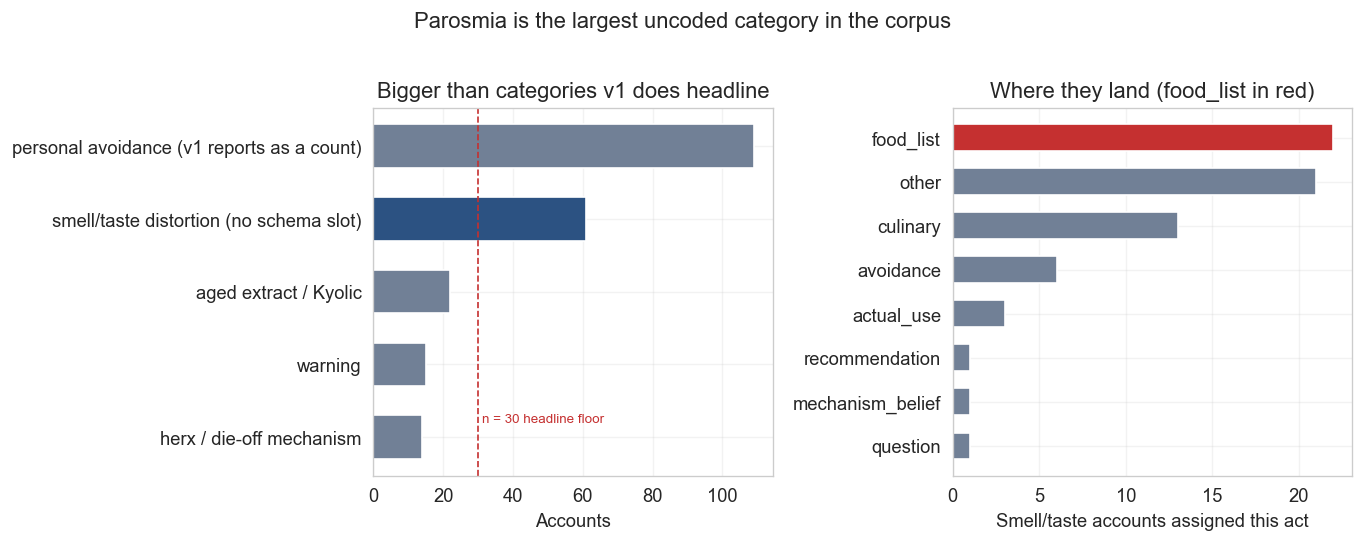

In [7]:

smell = set(TEXT.index[TEXT["smell_taste"]]) & set(COMPLETE)
land = pd.DataFrame([
    {"speech act": a, "smell/taste accounts": len(smell & set(ACTS.index[ACTS[a]])),
     "% of that act": len(smell & set(ACTS.index[ACTS[a]])) / max(int(ACTS[a].sum()), 1)}
    for a in G.SPEECH_ACTS
]).sort_values("smell/taste accounts", ascending=False)
land = land[land["smell/taste accounts"] > 0].reset_index(drop=True)
show(land, f"Where the {len(smell)} accounts describing smell/taste distortion land in a taxonomy with no slot "
           "for them. They can hold more than one act.",
     int_cols=("smell/taste accounts",), percent_cols=("% of that act",))

mech_smell = (F.mechanisms[F.mechanisms.reporter.isin(smell)]
              .groupby("mechanism").reporter.nunique().sort_values(ascending=False))
size_cmp = pd.DataFrame([
    {"category": "smell/taste distortion (no schema slot)", "accounts": len(smell)},
    {"category": "personal avoidance (v1 reports as a count)", "accounts": int(ACTS["avoidance"].sum())},
    {"category": "aged extract / Kyolic", "accounts": int(USE.loc[USE.preparation == "aged_extract_kyolic", "reporter"].nunique())},
    {"category": "warning", "accounts": int(ACTS["warning"].sum())},
    {"category": "herx / die-off mechanism", "accounts": int(F.mechanisms.loc[F.mechanisms.mechanism == "herx_or_dieoff", "reporter"].nunique())},
]).sort_values("accounts", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
y = np.arange(len(size_cmp))[::-1]
axes[0].barh(y, size_cmp["accounts"], height=0.6,
             color=[PALETTE["accent"] if "smell" in c else PALETTE["other"] for c in size_cmp["category"]])
axes[0].set_yticks(y, size_cmp["category"])
axes[0].axvline(G.MIN_REPORTERS, color="#c53030", ls="--", lw=1)
axes[0].text(G.MIN_REPORTERS + 1, 0.2, "n = 30 headline floor", color="#c53030", fontsize=8)
axes[0].set_xlabel("Accounts")
axes[0].set_title("Bigger than categories v1 does headline")
y2 = np.arange(len(land))[::-1]
axes[1].barh(y2, land["smell/taste accounts"], height=0.6,
             color=[PALETTE["food"] if a == "food_list" else PALETTE["other"] for a in land["speech act"]])
axes[1].set_yticks(y2, land["speech act"])
axes[1].set_xlabel("Smell/taste accounts assigned this act")
axes[1].set_title("Where they land (food_list in red)")
fig.suptitle("Parosmia is the largest uncoded category in the corpus", y=1.02)
fig_show(fig)

n_fl_smell = len(smell & set(ACTS.index[ACTS["food_list"]]))
callout("caution",
        f"<b>Contamination of the anti-use camp.</b> {len(smell)} accounts ({100*len(smell)/N_REP:.1f}%) describe "
        f"smell or taste distortion — larger than herx, warning or Kyolic, all of which v1 codes. "
        f"{n_fl_smell} of them are scored <code>food_list</code>. “Garlic tastes like garbage now” is being "
        f"counted as the same speech act as “garlic triggers my mast cells,” and it feeds the anti-use side of "
        f"the §1 contrast. Mechanisms assigned to these accounts are "
        f"{', '.join(f'{m} ({n})' for m, n in mech_smell.items()) or 'none'} — none of which is the right one.")


## 5. v1's own self-critique points the wrong way

v1 §2 worries that `culinary` overshoots its keyword floor (408 vs 201) while `food_list` undershoots (355 vs 536), and concludes "some list-shaped posts may be landing in `culinary`." That is checkable against the stored evidence quotes.


speech act,claims,listy,share with avoid/trigger/histamine language
culinary,494,5,1.0%
food_list,491,168,34.2%


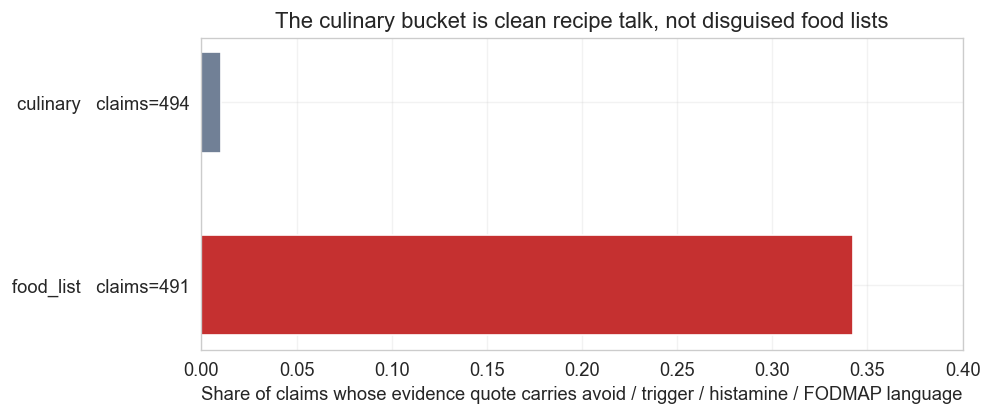

In [8]:

QF = quote_flags({"listy": LISTY_RE})
cq = F.claims.join(QF, on="claim_id")
bound = (cq[cq.speech_act.isin(["culinary", "food_list"])]
         .groupby("speech_act")
         .agg(claims=("claim_id", "size"), listy=("listy", "sum")))
bound["share with avoid/trigger/histamine language"] = bound["listy"] / bound["claims"]
show(bound.reset_index().rename(columns={"speech_act": "speech act"}),
     "Evidence-quote language for the two labels v1 suspected of bleeding into each other. If list-shaped posts "
     "were landing in <code>culinary</code>, the culinary row would carry trigger language.",
     int_cols=("claims", "listy"), percent_cols=("share with avoid/trigger/histamine language",))

fig, ax = plt.subplots(figsize=(8.4, 3.6))
y = np.arange(len(bound))[::-1]
ax.barh(y, bound["share with avoid/trigger/histamine language"], height=0.55,
        color=[PALETTE["other"] if a == "culinary" else PALETTE["food"] for a in bound.index])
ax.set_yticks(y, [f"{a}   claims={int(n):,}" for a, n in zip(bound.index, bound["claims"])])
ax.set_xlabel("Share of claims whose evidence quote carries avoid / trigger / histamine / FODMAP language")
ax.set_xlim(0, 0.4)
ax.set_title("The culinary bucket is clean recipe talk, not disguised food lists")
fig_show(fig)

callout("note",
        f"<b>The suspected leak is not there.</b> "
        f"{100*bound.loc['culinary', 'share with avoid/trigger/histamine language']:.0f}% of culinary quotes "
        f"carry trigger language against "
        f"{100*bound.loc['food_list', 'share with avoid/trigger/histamine language']:.0f}% of food_list quotes. "
        "The culinary overshoot is a bad keyword floor — a regex for recipe talk is hard to write — not label "
        "leakage. GATE 4's 5/12 is still unresolved, but §4 suggests the real confusion runs parosmia → "
        "food_list, which nobody looked for.")


## 6. Independence is weaker than the confidence intervals imply

Every Wilson interval in v1 treats one account as one independent draw. Two things complicate that: claim volume is very skewed, and the two camps are skewed differently.


camp,accounts,mean claims,median claims,single-claim %,has any polarity %
food_list only,312,1.70,1.00,71.8%,58.0%
actual_use only,607,2.63,1.00,53.7%,65.1%


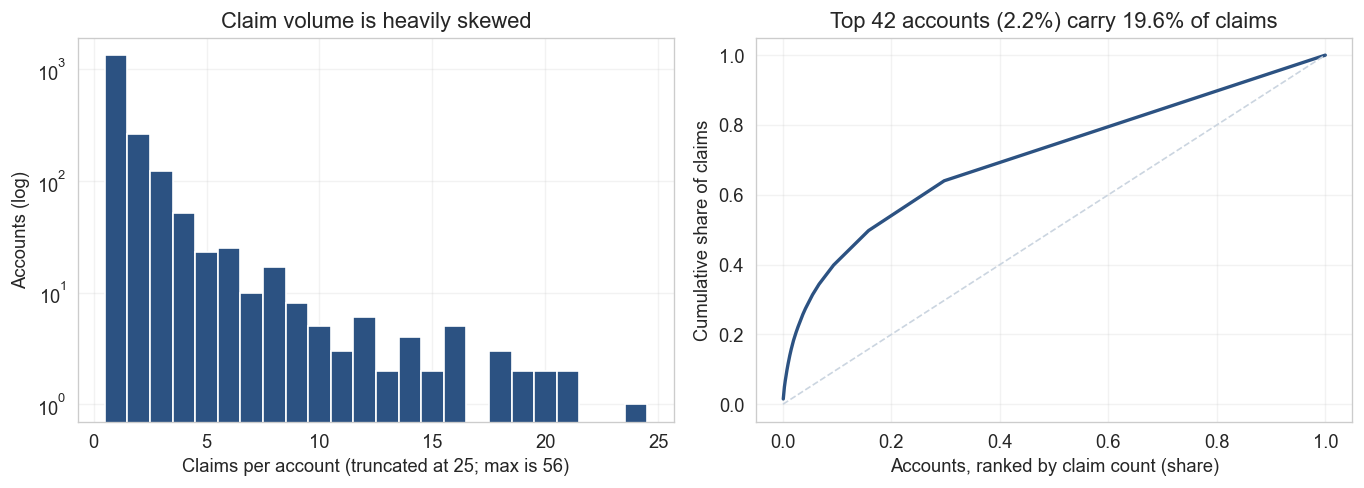

In [9]:

per = F.claims.groupby("reporter").size()
camp_stats = []
for camp, mask in (("food_list only", ONLY_FL), ("actual_use only", ONLY_AU)):
    ids = mask[mask].index
    n = per.reindex(ids).fillna(0)
    pol_ids = set(BELIEF[BELIEF.reporter.isin(set(ids))].reporter)
    camp_stats.append({
        "camp": camp, "accounts": len(ids), "mean claims": n.mean(),
        "median claims": n.median(), "single-claim %": (n == 1).mean(),
        "has any polarity %": len(pol_ids) / len(ids),
    })
show(pd.DataFrame(camp_stats),
     "The use camp writes more, so it has more chances to receive a polarity label. The §1 denominators are "
     "therefore not ascertained equally between camps.",
     int_cols=("accounts",), float_cols=("mean claims", "median claims"),
     percent_cols=("single-claim %", "has any polarity %"))

top = per.sort_values(ascending=False)
share_42 = top.head(42).sum() / top.sum()
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].hist(per, bins=np.arange(0.5, 25.5, 1), color=PALETTE["accent"])
axes[0].set_yscale("log")
axes[0].set_xlabel("Claims per account (truncated at 25; max is %d)" % int(per.max()))
axes[0].set_ylabel("Accounts (log)")
axes[0].set_title("Claim volume is heavily skewed")
cum = np.cumsum(top.values) / top.sum()
axes[1].plot(np.arange(1, len(cum) + 1) / len(cum), cum, color=PALETTE["accent"], lw=2)
axes[1].plot([0, 1], [0, 1], ls="--", lw=1, color="#cbd5e0")
axes[1].set_xlabel("Accounts, ranked by claim count (share)")
axes[1].set_ylabel("Cumulative share of claims")
axes[1].set_title(f"Top 42 accounts (2.2%) carry {100*share_42:.1f}% of claims")
fig_show(fig)

n_zero = N_REP - F.claims.reporter.nunique()
callout("note",
        f"<b>Read the intervals as optimistic.</b> {int((per >= 10).sum())} accounts carry "
        f"{100*per[per >= 10].sum()/per.sum():.1f}% of all claims. The food-list camp is "
        f"{100*camp_stats[0]['single-claim %']:.0f}% single-claim against "
        f"{100*camp_stats[1]['single-claim %']:.0f}% for the use camp, and differs in the rate at which it "
        f"receives any polarity at all ({100*camp_stats[0]['has any polarity %']:.0f}% vs "
        f"{100*camp_stats[1]['has any polarity %']:.0f}%) — differential ascertainment, not just noise. "
        f"Separately, {n_zero} complete-extraction accounts produced no claim and sit silently in every "
        "denominator. v1's sensitivity cut drops the top four accounts; the issue is the shape of the whole "
        "distribution.")


## 7. Revised tiers

Same rules as v1 (n ≥ 30 and p < 0.05 for Strong), applied to what survived §1–§6.


tier,finding,changed from v1
Strong,"Do not build a garlic-use cohort from a first-pass treatment field. The JSON-vs-FTS gap is flat across writing volume (OR 12.5–18.8 in every stratum), so it is a judgement encoded by the extractor, not a salience artefact.",promoted to lead
Moderate,"Garlic-as-list and garlic-as-treatment are different speech acts with opposite polarity. Real, but OR ≈ 15 and h ≈ 1.2 once polarity is sourced from a different claim — not OR 38.8.",demoted from Strong
Moderate,"Among self + actual-use accounts, 17.7% name an anticoagulant or fibrinolytic in the same windows, with almost no warning or bleeding-AE reporting. A reporting gap, not an incidence rate.",new
Preliminary,Parosmia / flavour loss is the largest uncoded category (61 accounts) and 22 of those are scored food_list. Needs a schema slot before the §1 contrast can be trusted at the margin.,new
Preliminary,"The culinary bucket is clean; GATE 4's failure is probably parosmia → food_list, not food_list → culinary. Still unadjudicated.",corrects v1's self-critique


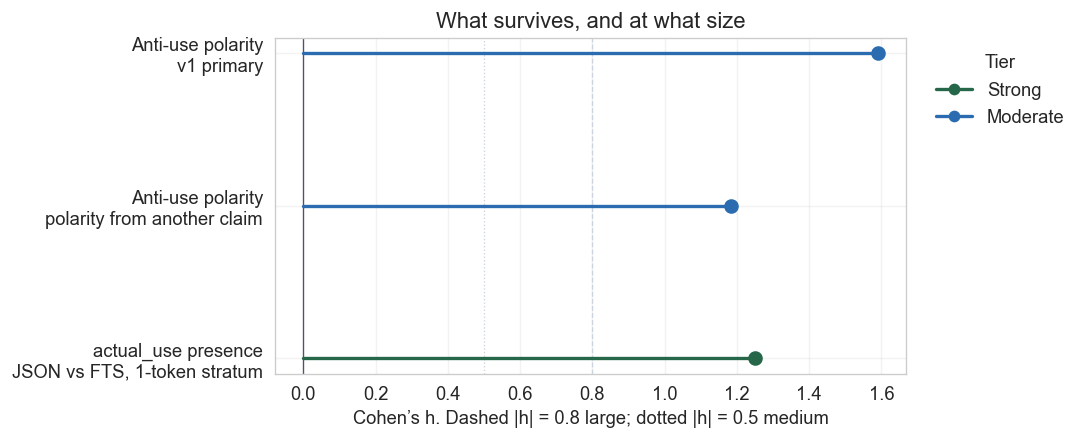

In [10]:

tiers = pd.DataFrame([
    {"tier": "Strong",
     "finding": "Do not build a garlic-use cohort from a first-pass treatment field. The JSON-vs-FTS gap is flat "
                "across writing volume (OR 12.5–18.8 in every stratum), so it is a judgement encoded by the "
                "extractor, not a salience artefact.",
     "changed from v1": "promoted to lead"},
    {"tier": "Moderate",
     "finding": "Garlic-as-list and garlic-as-treatment are different speech acts with opposite polarity. Real, "
                "but OR ≈ 15 and h ≈ 1.2 once polarity is sourced from a different claim — not OR 38.8.",
     "changed from v1": "demoted from Strong"},
    {"tier": "Moderate",
     "finding": "Among self + actual-use accounts, 17.7% name an anticoagulant or fibrinolytic in the same "
                "windows, with almost no warning or bleeding-AE reporting. A reporting gap, not an incidence rate.",
     "changed from v1": "new"},
    {"tier": "Preliminary",
     "finding": "Parosmia / flavour loss is the largest uncoded category (61 accounts) and 22 of those are scored "
                "food_list. Needs a schema slot before the §1 contrast can be trusted at the margin.",
     "changed from v1": "new"},
    {"tier": "Preliminary",
     "finding": "The culinary bucket is clean; GATE 4's failure is probably parosmia → food_list, not "
                "food_list → culinary. Still unadjudicated.",
     "changed from v1": "corrects v1's self-critique"},
])
show(tiers, "Everything here is about how to read the corpus and the pipeline. Nothing here is about whether "
            "garlic works, which this design cannot answer.")

h_rows = [
    ("Anti-use polarity\nv1 primary", primary["h"], "Moderate"),
    ("Anti-use polarity\npolarity from another claim", cross["h"], "Moderate"),
]
if len(strat):
    j0 = strat.iloc[0]
    h_rows.append(("actual_use presence\nJSON vs FTS, 1-token stratum",
                   G.cohens_h(j0["JSON actual_use"], j0["FTS-only actual_use"]), "Strong"))
tier_color = {"Strong": "#276749", "Moderate": "#2b6cb0", "Preliminary": "#dd6b20"}
labels, hs, ts = zip(*h_rows)
y = np.arange(len(labels))[::-1]
fig, ax = plt.subplots(figsize=(9.2, 3.8))
ax.axvline(0, color="#4a5568", lw=0.8)
for v, ls in ((0.8, "--"), (0.5, ":")):
    ax.axvline(v, color="#cbd5e0", ls=ls, lw=0.8)
for yi, h, t in zip(y, hs, ts):
    ax.plot([0, h], [yi, yi], color=tier_color[t], lw=2)
    ax.scatter([h], [yi], color=tier_color[t], s=60, zorder=3)
ax.set_yticks(y, labels)
ax.set_xlabel("Cohen’s h. Dashed |h| = 0.8 large; dotted |h| = 0.5 medium")
handles = [plt.Line2D([0], [0], marker="o", color=c, label=t, lw=2)
           for t, c in tier_color.items() if t in ts]
ax.legend(handles=handles, title="Tier", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
ax.set_title("What survives, and at what size")
fig_show(fig)


## 8. Conclusion

v1's story holds in shape and shrinks in size. Garlic really is two folk systems sharing a word: one camp lists it as a trigger, another takes it as a treatment, and their polarity runs in opposite directions. But the 39-fold odds ratio was measuring a single model deciding both facts about one sentence at once. Asked to derive the two labels from different sentences by the same account, the community difference is about OR 15 — still large, still the right qualitative reading, and roughly a third of the advertised effect.

The finding that should lead is the methods one, because it is the one that got harder to explain away rather than easier. A first-pass treatment extractor and a full-text gate retrieve different populations from the same corpus, and they do so at the same rate whether an account wrote one garlic sentence or fifty. Anyone assembling a cohort from an extracted-treatment field in this database is selecting on the pipeline's implicit theory of what counts as a treatment, and that selection is strong enough to invert which camp looks like the majority.

Two things this corpus contains and neither notebook's schema anticipated. Accounts using garlic are twice as likely as the cohort to be writing about nattokinase, serrapeptase or a prescription anticoagulant in the same breath — they are pursuing garlic's antiplatelet effect on purpose, as part of the microclot protocol, and the corpus produces almost no warnings and almost no bleeding reports to go with it. And parosmia, which garlic is an unusually good probe for, is the largest category with no label at all; a fifth of those accounts are being filed as histamine food lists.

What remains open is unchanged from v1 and now more pointed: GATE 4 never cleared, and §4 and §5 together suggest the unresolved boundary is not the one v1 suspected. Adding a parosmia speech act and re-running the same windows would cost little and would test the §1 contrast at its weakest margin.


## 9. Limitations specific to v2

**Same store, same model, same run.** Nothing was re-extracted. Every v1 limitation carries: self-selected posters, no control arm, positive labels over-called by roughly 10–20%, `not_stated` as the majority for adverse events, and a `deepseek/deepseek-v4-flash` extractor that agrees with itself on `speech_act` only 79.4% of the time at temperature 0. That instability is a floor under every contrast here, including the ones v2 adds.

**The cross-claim test trades circularity for power.** Restricting polarity to non-camp claims leaves 29 food-list and 114 actual-use accounts. The direction is unambiguous, the magnitude is not. OR 15.3 should be read as "large, and smaller than 38.8," not as a point estimate. It is also not fully independent: both claims come from one account, one model and often one window.

**Co-mention is not co-ingestion.** §3's anticoagulant flag fires when a drug or enzyme name appears anywhere in an account's garlic windows. Some of those accounts are discussing, not combining. The flag is an upper bound on stacking. The reporting gap it measures — 2 warnings across 113 accounts — is robust to that, because the denominator being loose only makes the numerator more surprising.

**The parosmia flag is a regex, not a label.** §4 counts accounts whose windows match smell/taste-distortion language. It has no adjudication behind it and will both over- and under-fire. It is offered as evidence that a category is missing, not as a measurement of how many people have parosmia.

**No multiplicity control on the new contrasts.** §3, §4 and §5 are three planned follow-ups to a specific reading of v1, not a scan. They are reported unadjusted and tiered accordingly. The only FDR-controlled family in this study remains v1's eight-mechanism scan.

**Regex flags see the whole window, labels see a claim.** The text flags in §3, §4 and §6 operate on an account's concatenated garlic windows, while speech acts are per-claim. Joining the two levels attributes window context to claim labels, which is exactly the confound §1 criticises v1 for — applied here to generate hypotheses rather than to size an effect.


In [11]:

prov = G.provenance_table(F)
extra = pd.DataFrame([
    {"item": "notebook", "value": "studies/garlic/analysis_grok/garlic_beliefs_and_use_v2.ipynb"},
    {"item": "supersedes", "value": "garlic_beliefs_and_use.ipynb (v1) — same run_id, no re-extraction"},
    {"item": "extraction model", "value": F.run["config"].get("model", "—")},
    {"item": "v2 additions", "value": "cross-claim polarity contrast; salience-stratified JSON/FTS; "
                                      "anticoagulant co-mention; parosmia flag; quote-language boundary check"},
    {"item": "text handling", "value": "window text and evidence quotes are reduced to booleans inside "
                                       "text_flags()/quote_flags() and never returned"},
])
show(pd.concat([prov, extra], ignore_index=True), "Provenance. Database SHA-256 is of the probe store; do not commit that file.")

try:
    agr, ctx = G.repeat_agreement()
    show(agr, f"Stage 5b temperature-0 repeat, unchanged from v1 (units complete in both stores: "
              f"{ctx['units complete in both']}; claim pairs: {ctx['claim pairs']}). This is the instability "
              "floor under every number above.",
         percent_cols=("rate",), int_cols=("n", "of"))
except FileNotFoundError:
    callout("note", "Repeat-pass database not found; Stage 5b agreement is in docs/garlic_probe_run_report.md.")


item,value
database,garlic_pharmacology.db
database SHA-256,7caae438b3512ea0cb4a59f2956d3417b0b7abfde34a234dfab3e7b3d32eb4f0
run ID (pinned),c05891b6ecad47900230eb606afbb230a9867fc9f41d1d2b88ec0292a05b03df
run created,2026-08-12T23:40:00.979171+00:00
model,deepseek/deepseek-v4-flash
provider / base URL,openai / https://openrouter.ai/api
sampling,"temperature 0.0, max_tokens 32,768, reasoning_effort medium"
HTTP timeout (not in run_id),"connect=10, read=90, write=90, pool=60"
prompt version,2026-08-12-v3 (short-paraphrase contract)
quote grounding floor,"0.5 bag-of-words, no verbatim companion"


metric,n,of,rate
top-level field set identical,52,68,76.5%
shared top-level values equal,541,609,88.8%
all shared fields equal identical,21,68,30.9%
speech_act identical,54,68,79.4%
subject identical,61,68,89.7%
exposure_status identical,61,68,89.7%
polarity identical,53,68,77.9%
preparation identical,63,68,92.6%


In [12]:

display(HTML(
    "<p style='font-size:1.2em;font-weight:bold;font-style:italic;margin-top:1.2em'>"
    "These findings reflect reporting patterns in online communities, not population-level "
    "treatment effects. This is not medical advice.</p>"
))
